## Download Dataset

In [1]:
!kaggle datasets download -d jangedoo/utkface-new -p /home/midori/Desktop/Nural_Network/Data

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100%|████████████████████████████████████████| 331M/331M [02:24<00:00, 2.40MB/s]



In [2]:
from zipfile import ZipFile
from pathlib import Path

In [4]:
zip_path = "/home/midori/Desktop/Nural_Network/Data/utkface-new.zip"
extract_path = "/home/midori/Desktop/Nural_Network/Data/"

In [5]:
with ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"Extracted to: {extract_path}")

Extracted to: /home/midori/Desktop/Nural_Network/Data/


## source

In [1]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

I0000 00:00:1778051843.498644   23906 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778051843.499202   23906 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778051843.554685   23906 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778051845.067874   23906 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
folder_path = "/home/midori/Desktop/Nural_Network/Data/utkface_aligned_cropped/UTKFace/"

In [3]:
example = "1_0_0_20161219211413621.jpg.chip.jpg"


# split returns a list of string

new_list = example.split('_')

print(new_list)
print('age: ',new_list[0])
print('Gender: ',new_list[1])

# 0 --> male
# 1 --> female

['1', '0', '0', '20161219211413621.jpg.chip.jpg']
age:  1
Gender:  0


In [3]:
age=[]
gender=[]
img_path=[]

for file in os.listdir(folder_path):
  age.append(int(file.split('_')[0]))    # first number == Age
  gender.append(int(file.split('_')[1])) # second number == Gender
  img_path.append(file)

### creating dataframe

In [4]:
df = pd.DataFrame({'age':age, 'gender':gender, 'img':img_path})
df.shape

(23708, 3)

In [5]:
df.head()

,age,gender,img
0,100,0,100_0_0_20170112213500903.jpg.chip.jpg
1,100,0,100_0_0_20170112215240346.jpg.chip.jpg
2,100,1,100_1_0_20170110183726390.jpg.chip.jpg
3,100,1,100_1_0_20170112213001988.jpg.chip.jpg
4,100,1,100_1_0_20170112213303693.jpg.chip.jpg


In [8]:
# from sklearn.model_selection import train_test_split

# train_df, test_df = train_test_split(
#     df,
#     test_size=0.2,
#     random_state=0,
#     stratify=df['gender']
# )

# ------------------------------------------------------------------------------------

# X = df.drop('gender', axis=1)
# y = df['gender']

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=0,
#     stratify=y
# )

# ------------------------------------------------------------------------------------

# manual train-test split
# shuffled_df = df.sample(frac=1, random_state=0)

# train_df = shuffled_df.iloc[:20000]
# test_df = shuffled_df.iloc[20000:]

# frac=1 ---> means take 100% of rows and sample randomly rearranges them

# Shuffle entire dataframe
# ↓
# Take first 20k rows → training
# Take remaining rows → testing

# -------------------------------------------------------------------------------------
# doing manual stratified split

# seperate classes and suffle
male_class = df[df['gender']==0].sample(frac=1, random_state=11)
female_class = df[df['gender']==1].sample(frac=1, random_state=11)

# 80-20 number
male_80 = int(0.8*len(male_class))
female_80 = int(0.8*len(female_class))

# 80-20 split
train_male = male_class.iloc[:male_80]
train_female = female_class.iloc[:female_80]

test_male = male_class.iloc[male_80:]
test_female = female_class.iloc[female_80:]

train_df = pd.concat([train_male,train_female], ignore_index=True).sample(frac=1, random_state=11).reset_index(drop=True)
test_df = pd.concat([test_male,test_female], ignore_index=True).sample(frac=1, random_state=11).reset_index(drop=True)
# first while concatenating we are reseting the index and now after sampling we are again reseting the index


In [9]:
train_df.shape

(18965, 3)

In [10]:
test_df.shape

(4743, 3)

In [ ]:
# DATA-AUGMENTATION -havenot studies yet properly

# train_datagen = ImageDataGenerator(rescale=1./255,
#                                    rotation_range=30,
#                                    width_shift_range=0.2,
#                                    height_shift_range=0.2,
#                                    shear_range=0.2,
#                                    zoom_range=0.2,
#                                    horizontal_flip=True)

# test_datagen = ImageDataGenerator(rescale=1./255)

### Normalization

In [138]:
from keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import *
from keras.models import Model

In [139]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [140]:
from keras.applications.efficientnet import preprocess_input

In [141]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [179]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=folder_path,
    x_col='img',
    y_col=['age', 'gender'],
    target_size=(120,120),
    class_mode='raw',
    batch_size=16,
    shuffle=True
)


Found 18965 validated image filenames.


In [180]:

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=folder_path,
    x_col='img',
    y_col=['age', 'gender'],
    target_size=(120,120),
    class_mode='raw',
    batch_size=16,
    shuffle=False
)

Found 4743 validated image filenames.


In [181]:
def custom_generator(generator):
    while True:
        x_batch, y_batch = next(generator)

        yield (
            x_batch,
            {
                'age': y_batch[:, 0],
                'gender': y_batch[:, 1]
            }
        )

In [182]:
train_gen = custom_generator(train_generator)
test_gen = custom_generator(test_generator)

## Non-sequential model

In [199]:
conv_layer = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(120,120,3)
)

In [200]:
conv_layer.trainable = False

# output = conv_layer.layers[-1].output
output = conv_layer.output

In [201]:
# GlobalAveragePooling2D reduces parameter explosion compared to Flatten
x = GlobalAveragePooling2D()(output)

In [202]:
output

<KerasTensor shape=(None, 3, 3, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_724>

In [203]:
x

<KerasTensor shape=(None, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_725>

In [204]:
common_dense = Dense(64, activation='relu')(x)

In [205]:
age_branch = Dense(32, activation='relu')(common_dense)
gender_branch = Dense(32, activation='relu')(common_dense)

In [206]:
age_output = Dense(1, activation='linear', name='age')(age_branch)
gender_output = Dense(1, activation='sigmoid', name='gender')(gender_branch)

In [207]:
model = Model(inputs=conv_layer.input, outputs=[age_output,gender_output])

In [208]:
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 120, 120,  │      1,792 │ input_layer_9[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 120, 120,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 60, 60,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 60, 60,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 60, 60,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 30, 30,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 30, 30,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 30, 30,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 30, 30,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 15, 15,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 15, 15,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 15, 15,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 15, 15,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 7, 7, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 7, 7, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 7, 7, 512) │  2,359,808 │ block5_conv1[0][

 Total params: 14,751,746 (56.27 MB)

 Trainable params: 37,058 (144.76 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

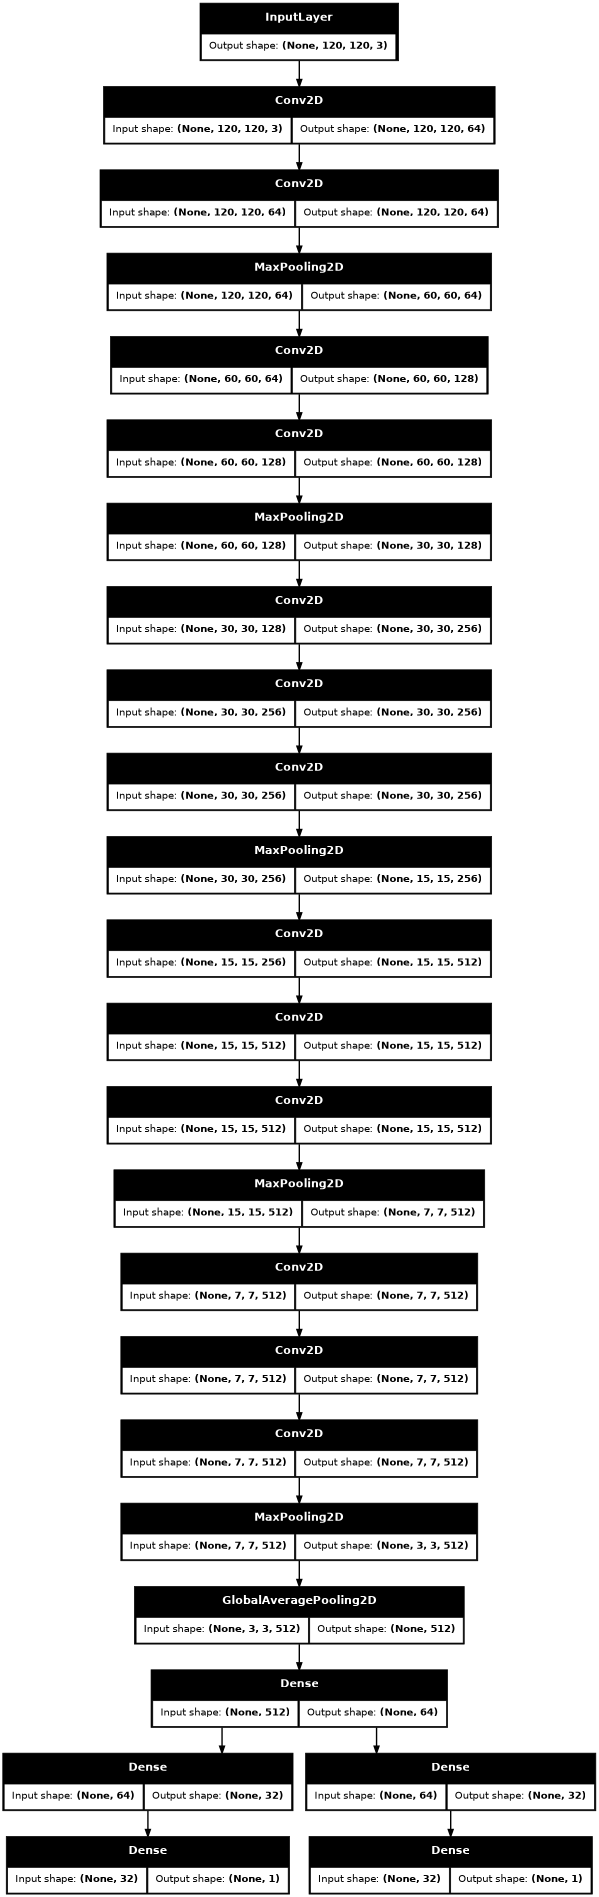

In [209]:
from keras.utils import plot_model
plot_model(model, dpi=50, rankdir='TB', show_shapes=True)

In [210]:
# Flatten preserves all spatial activations separately.
# The model can still learn WHERE a feature appeared in the feature map.

# GlobalAveragePooling2D averages each feature map into a single value.
# The model keeps HOW STRONGLY a feature exists overall,
# while discarding exact spatial location information.

In [211]:
model.compile(
    optimizer='adam',
    loss={
        'age': 'mae',
        'gender': 'binary_crossentropy'
    },
    metrics={
        'age': 'mae',
        'gender': 'accuracy'
    }
)

In [212]:
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_generator),
    validation_data=test_gen,
    validation_steps=len(test_generator),
    epochs=10,
    verbose=1
)

Epoch 1/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 927s 781ms/step - age_loss: 10.3911 - age_mae: 10.3918 - gender_accuracy: 0.7720 - gender_loss: 0.5251 - loss: 10.9172 - val_age_loss: 9.5225 - val_age_mae: 9.5241 - val_gender_accuracy: 0.7963 - val_gender_loss: 0.4305 - val_loss: 9.9535
Epoch 2/10
 611/1186 ━━━━━━━━━━━━━━━━━━━━ 5:37 588ms/step - age_loss: 9.2575 - age_mae: 9.2575 - gender_accuracy: 0.8025 - gender_loss: 0.4333 - loss: 9.6907

KeyboardInterrupt: 

In [ ]:
# https://machinelearningmastery.com/keras-functional-api-deep-learning/